# XAI Fundamentals & Curated Example Set

**Tasks:**
1. Conceptual understanding of XAI (local vs global, attribution methods, why explainability matters for multimodal models)
2. Select 10â€“15 representative images from Week 2 results (mix of good and poor captions)
3. Save curated set (image + generated caption + ground truth captions) to `data/xai_examples/`

**Selection criteria:**
- 5 **good** captions (high individual METEOR) â€” model got it right, Grad-CAM should show sensible focus
- 5 **poor** captions (low individual METEOR) â€” model failed, Grad-CAM may reveal why (wrong focus area)
- 3â€“5 **interesting** cases (medium METEOR but caption describes a different aspect than references)

## 1. Configuration

In [2]:
import json
import random
from pathlib import Path

import evaluate
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import torch
from PIL import Image
from transformers import BlipForConditionalGeneration, BlipProcessor

import os
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_ROOT = Path("../../data/flickr8k")
XAI_DIR = Path("../../data/xai_examples")

CAPTION_FILE = DATA_ROOT / "captions.txt"
IMAGE_DIR = DATA_ROOT / "Images"
if not IMAGE_DIR.exists():
    IMAGE_DIR = DATA_ROOT / "images"

XAI_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "Salesforce/blip-image-captioning-base"
RANDOM_SEED = 42
SAMPLE_SIZE = 200

print("Device:", DEVICE)
print("Images:", IMAGE_DIR)
print("XAI output:", XAI_DIR)

c:\Users\Fast Computer\Desktop\multi-layer-project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Images: ..\..\data\flickr8k\Images
XAI output: ..\..\data\xai_examples


## 2. Load Model and Data

In [3]:
processor = BlipProcessor.from_pretrained(MODEL_NAME)
model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()
print("BLIP loaded.")

captions = pd.read_csv(CAPTION_FILE)
captions.columns = [str(c).strip().lower().replace("_", "_") for c in captions.columns]

all_images = [img for img in captions["image"].drop_duplicates().tolist()
              if (IMAGE_DIR / img).exists()]
random.seed(RANDOM_SEED)
sample_images = random.sample(all_images, min(SAMPLE_SIZE, len(all_images)))
print(f"Will evaluate {len(sample_images)} images to find best/worst examples.")

Loading weights: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 473/473 [00:00<00:00, 5228.62it/s]


BLIP loaded.
Will evaluate 200 images to find best/worst examples.


## 3. Generate Captions and Compute Per-Image METEOR

In [4]:
for resource in ["wordnet", "omw-1.4", "punkt", "punkt_tab"]:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource, quiet=True)

meteor_metric = evaluate.load("meteor")

GENERATION_CONFIG = {"max_new_tokens": 30, "num_beams": 5, "early_stopping": True}

results = []
for img_name in sample_images:
    # Generate caption
    with Image.open(IMAGE_DIR / img_name) as image:
        rgb = image.convert("RGB")
    inputs = {k: v.to(DEVICE) for k, v in processor(images=rgb, return_tensors="pt").items()}
    with torch.inference_mode():
        out = model.generate(**inputs, **GENERATION_CONFIG)
    generated = processor.decode(out[0], skip_special_tokens=True).strip()

    # Get reference captions
    refs = captions.loc[captions["image"] == img_name, "caption"].astype(str).tolist()

    # Compute METEOR for this single image
    score = meteor_metric.compute(predictions=[generated], references=[refs])
    results.append({
        "image": img_name,
        "generated_caption": generated,
        "reference_captions": refs,
        "meteor": round(score["meteor"] * 100, 2),
    })

results_df = pd.DataFrame(results)
print(f"Evaluated {len(results_df)} images.")
print(f"METEOR range: {results_df['meteor'].min():.1f} â€” {results_df['meteor'].max():.1f}")
print(f"Mean METEOR: {results_df['meteor'].mean():.1f}")

[nltk_data] Downloading package wordnet to C:\Users\Fast
[nltk_data]     Computer\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Fast
[nltk_data]     Computer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Fast
[nltk_data]     Computer\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Evaluated 200 images.
METEOR range: 3.1 â€” 99.9
Mean METEOR: 36.0


## 4. Select Curated Examples (Good / Poor / Interesting)

In [5]:
# Sort by METEOR score
results_df = results_df.sort_values("meteor", ascending=False).reset_index(drop=True)

# Top 5 (good captions)
good = results_df.head(5)

# Bottom 5 (poor captions)
poor = results_df.tail(5)

# Middle 5 (interesting â€” medium METEOR, model captured something different)
mid_start = len(results_df) // 2 - 2
interesting = results_df.iloc[mid_start:mid_start + 5]

curated = pd.concat([good, interesting, poor], ignore_index=True)
curated["category"] = (["good"] * 5) + (["interesting"] * 5) + (["poor"] * 5)

print(f"Curated set: {len(curated)} images")
print(curated[["image", "category", "meteor", "generated_caption"]].to_string(index=False))

Curated set: 15 images
                    image    category  meteor                           generated_caption
2774705720_1cb85812dc.jpg        good   99.93       a couple sitting on a bench in a park
 428483413_b9370baf72.jpg        good   82.42 a man and a woman walking by a store window
3703107969_175da4b276.jpg        good   79.34               a man doing a trick on a bike
3126752627_dc2d6674da.jpg        good   76.53                  two men playing basketball
2953861572_d654d9b6f2.jpg        good   75.50                   a dog running in the sand
1072153132_53d2bb1b60.jpg interesting   35.71                  the dog is black and white
1100214449_d10861e633.jpg interesting   35.71         water fountain in front of building
1876536922_8fdf8d7028.jpg interesting   35.71               two dogs playing in the water
3359636318_39267812a0.jpg interesting   35.46   a group of people walking down the street
2021613437_d99731f986.jpg interesting   35.46  a young boy playing with a bas

## 5. Visualize Curated Examples

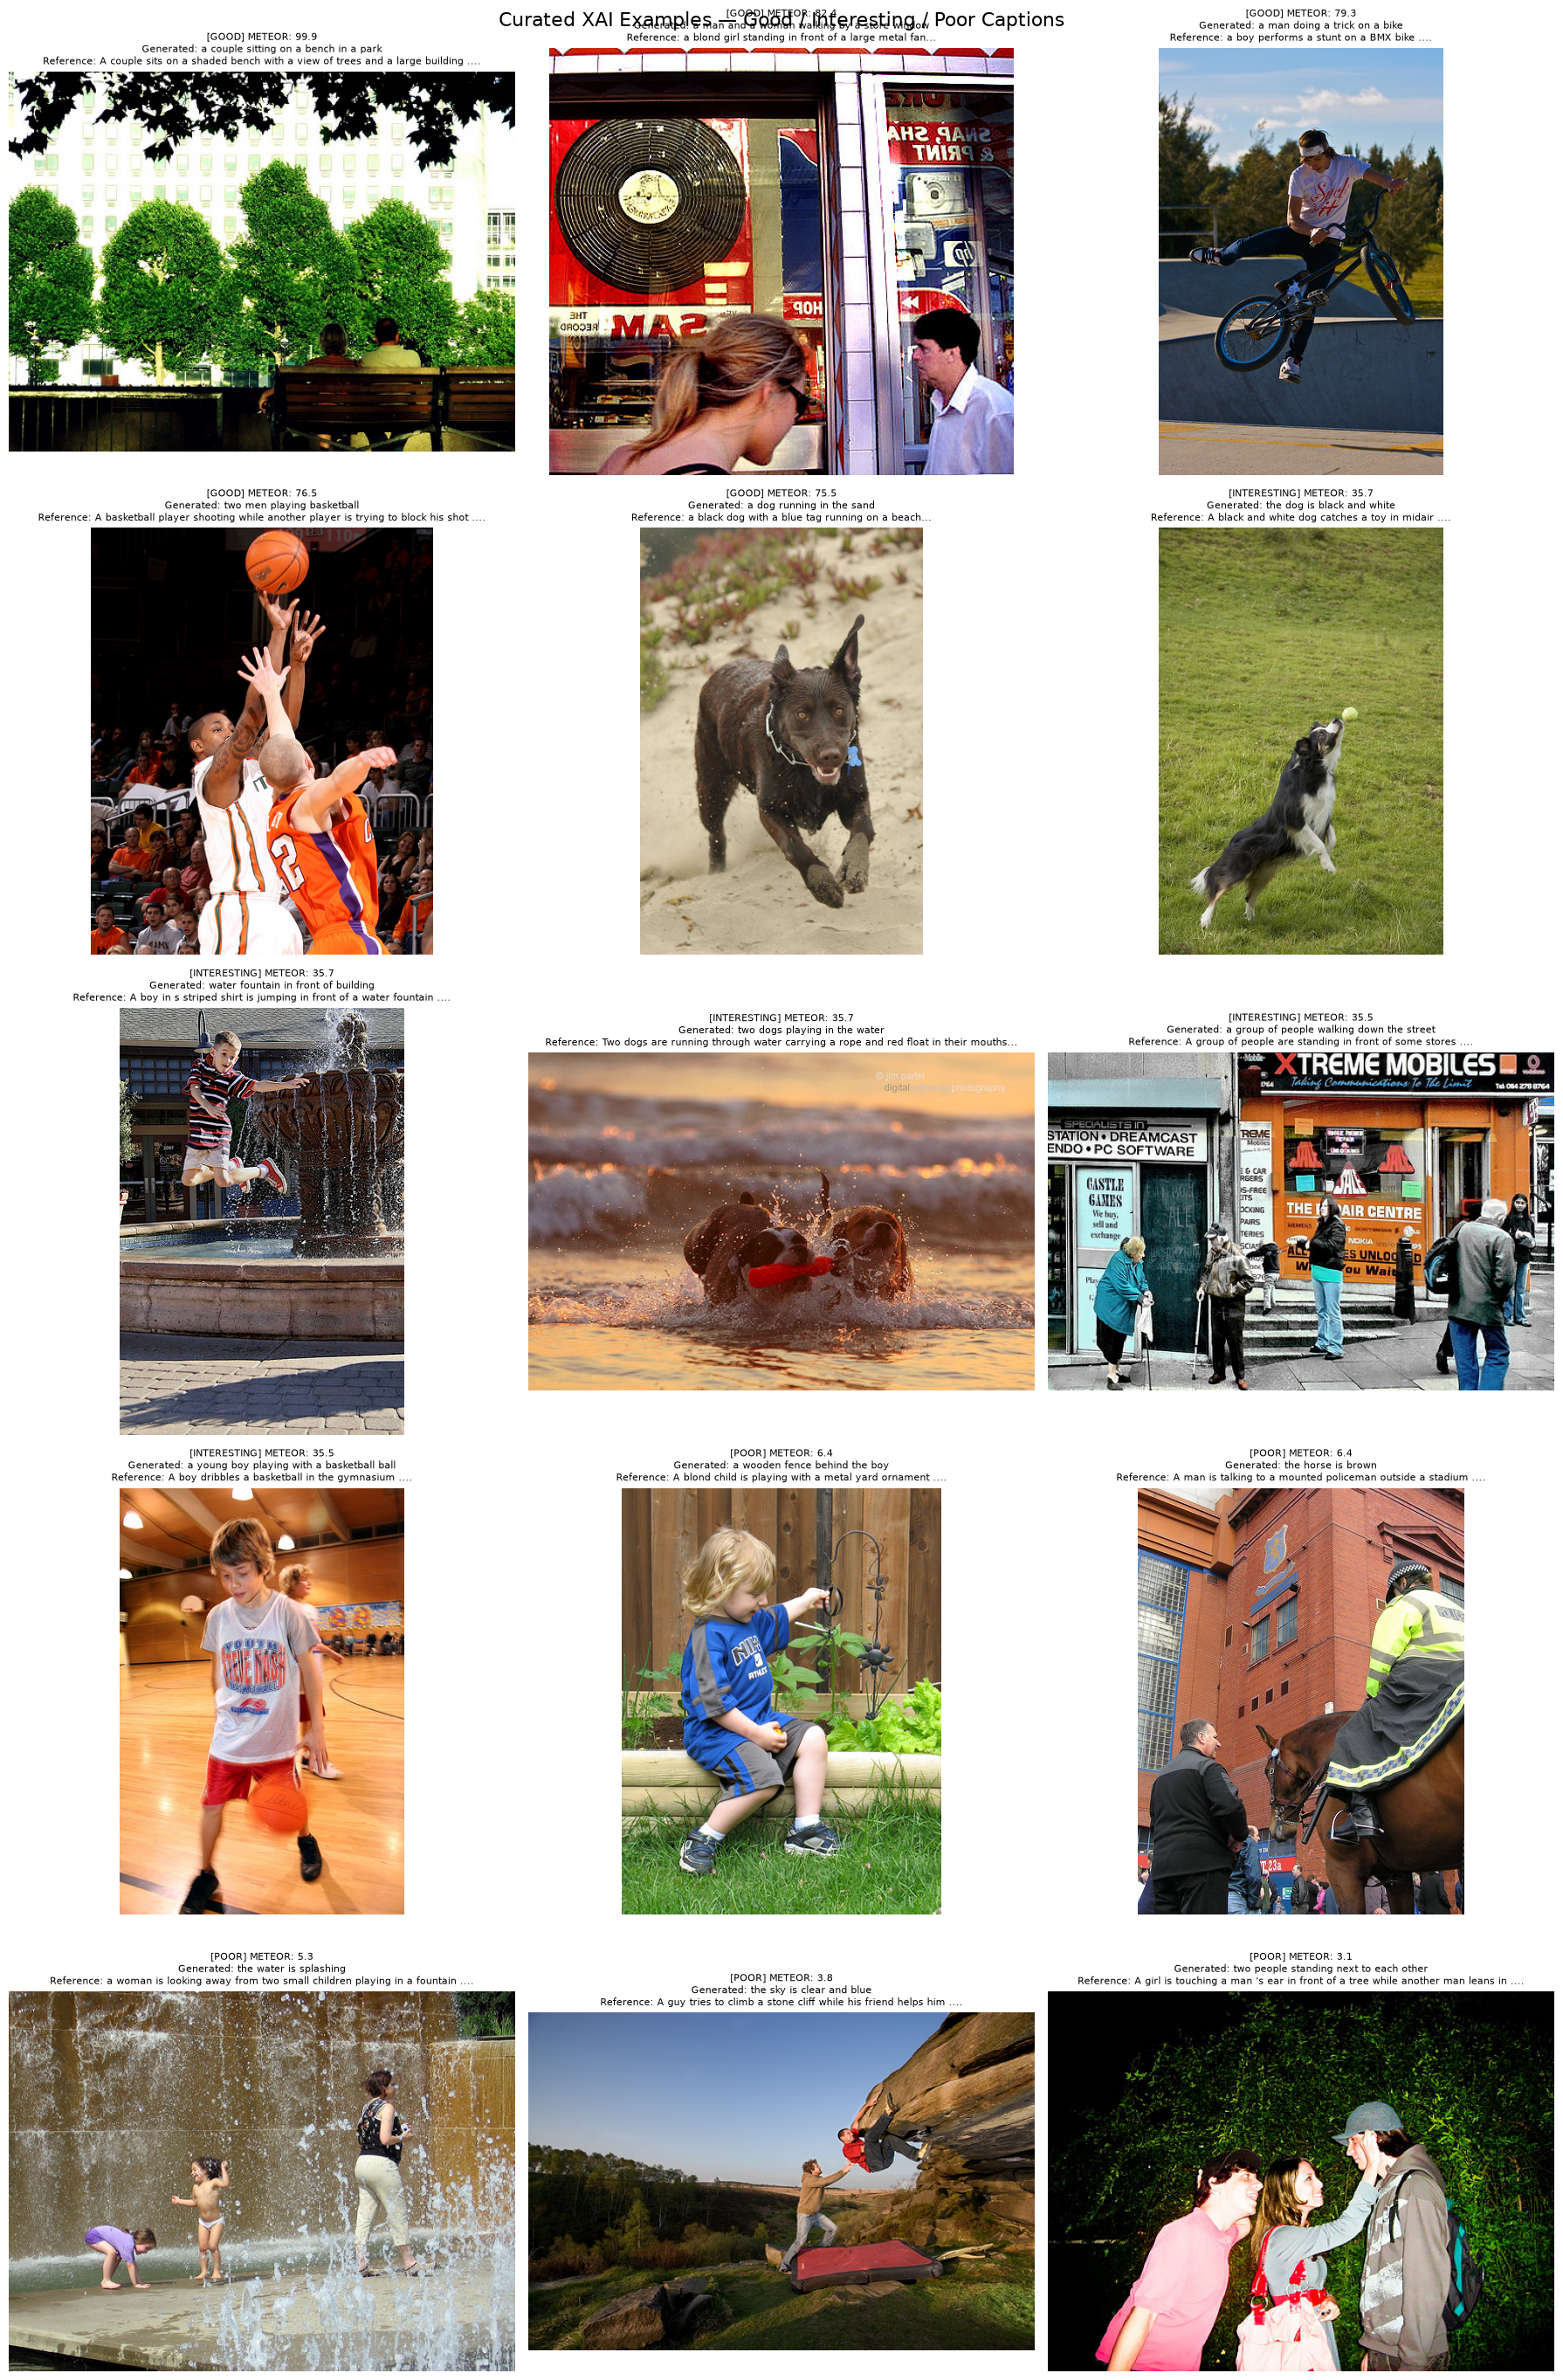

Grid saved to ..\..\data\xai_examples\curated_examples_grid.png


In [6]:
fig, axes = plt.subplots(5, 3, figsize=(18, 28))
fig.suptitle("Curated XAI Examples â€” Good / Interesting / Poor Captions", fontsize=16, y=0.98)

for idx, (_, row) in enumerate(curated.iterrows()):
    ax = axes[idx // 3, idx % 3]
    with Image.open(IMAGE_DIR / row["image"]) as img:
        ax.imshow(img)
    ax.set_title(
        f"[{row['category'].upper()}] METEOR: {row['meteor']:.1f}\n"
        f"Generated: {row['generated_caption']}\n"
        f"Reference: {row['reference_captions'][0][:80]}...",
        fontsize=8, wrap=True
    )
    ax.axis("off")

# Hide any empty subplots
for idx in range(len(curated), 15):
    axes[idx // 3, idx % 3].axis("off")

plt.tight_layout()
plt.savefig(str(XAI_DIR / "curated_examples_grid.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Grid saved to", XAI_DIR / "curated_examples_grid.png")

## 6. Save Curated Set to `data/xai_examples/`

In [7]:
import shutil

# Save metadata JSON (used by Day 2 and Day 3 notebooks)
curated_data = []
for _, row in curated.iterrows():
    # Copy image to xai_examples folder
    src = IMAGE_DIR / row["image"]
    dst = XAI_DIR / row["image"]
    shutil.copy2(str(src), str(dst))

    curated_data.append({
        "image": row["image"],
        "generated_caption": row["generated_caption"],
        "reference_captions": row["reference_captions"],
        "meteor": row["meteor"],
        "category": row["category"],
    })

with open(XAI_DIR / "curated_examples.json", "w") as f:
    json.dump(curated_data, f, indent=2)

# Also save as CSV for quick viewing
curated[["image", "category", "meteor", "generated_caption"]].to_csv(
    XAI_DIR / "curated_examples.csv", index=False)

print(f"Saved to {XAI_DIR}:")
for f in sorted(XAI_DIR.iterdir()):
    print(f"  {f.name} ({f.stat().st_size / 1024:.0f} KB)")

Saved to ..\..\data\xai_examples:
  1072153132_53d2bb1b60.jpg (132 KB)
  1100214449_d10861e633.jpg (172 KB)
  1876536922_8fdf8d7028.jpg (121 KB)
  2021613437_d99731f986.jpg (107 KB)
  2474918824_88660c7757.jpg (110 KB)
  2774705720_1cb85812dc.jpg (200 KB)
  2852982055_8112d0964f.jpg (179 KB)
  2953861572_d654d9b6f2.jpg (83 KB)
  3126752627_dc2d6674da.jpg (137 KB)
  3184112120_6ddcd98016.jpg (182 KB)
  3359636318_39267812a0.jpg (158 KB)
  3564007203_df2b8010f1.jpg (167 KB)
  3703107969_175da4b276.jpg (108 KB)
  3738685861_8dfff28760.jpg (178 KB)
  428483413_b9370baf72.jpg (152 KB)
  curated_examples.csv (1 KB)
  curated_examples.json (8 KB)
  curated_examples_grid.png (12881 KB)
